# BLiSS 1.0 usage example

This notebook shows how to load a spectrum, run the BLiSS line-search pipeline, inspect candidate lines, and generate ISIS helper files when needed.

In [29]:
from pathlib import Path
import sys

# Use the local package when running the notebook from the repository.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bliss


from bliss import (
    load_text_spectrum,
    load_fits_spectrum,
    rebin_bins,
    rebin_snr,
    rebin_resolution,
    find_emission_lines,
    add_most_probable_ion,
    get_all_compatible_lines,
    plot_line_prob,
    create_bliss_results_folder,
)
from bliss.isis_interface import write_isis_line_model_files, run_bliss_for_isis

print("Using BLiSS from:", bliss.__file__)

Using BLiSS from: /Users/graciela/Desktop/git/BLiSS/bliss/__init__.py


## 1. Create a timestamped output folder

Every run creates a folder named as:

```text
results/YYYY-MM-DD_HH-MM-SS_bliss/
```

This avoids overwriting previous runs and makes each analysis traceable.

In [20]:
results_dir = create_bliss_results_folder(PROJECT_ROOT / "results", "bliss")
results_dir

PosixPath('/Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-51-49_bliss')

## 2. Load a spectrum from a text file

The text loader reads the standard four-column BLiSS format:

```text
E_low   E_high   spectral_value   uncertainty
```

It returns arrays compatible with the old-style BLiSS call.

In [21]:
text_path = PROJECT_ROOT / "examples" / "xmm.dat"
energy, values, errors, bin_width = load_text_spectrum(text_path)

print(energy.shape, values.shape, errors.shape)
print("Energy range:", energy.min(), energy.max())

(242,) (242,) (242,)
Energy range: 0.3400000035762787 9.980000019073486


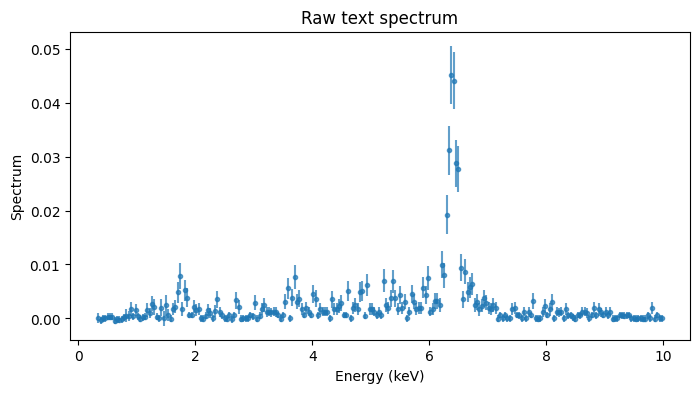

In [22]:
plt.figure(figsize=(8, 4))
plt.errorbar(energy, values, yerr=errors, fmt=".", alpha=0.7)
plt.xlabel("Energy (keV)")
plt.ylabel("Spectrum")
plt.title("Raw text spectrum")
plt.show()

## 3. Rebinning options

The modular package keeps the same rebinning functions used by the old example:

- `rebin_bins`
- `rebin_snr`
- `rebin_resolution`

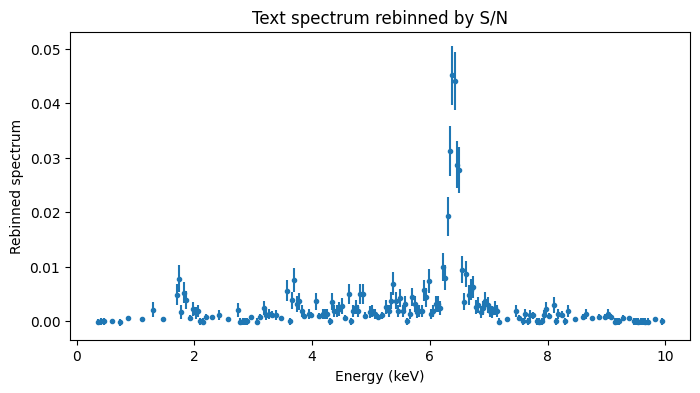

In [23]:
rx_bins, ry_bins, rsy_bins = rebin_bins(energy, values, errors, 1)
rx_snr, ry_snr, rsy_snr = rebin_snr(energy, values, errors, 0.8)

plt.figure(figsize=(8, 4))
plt.errorbar(rx_snr, ry_snr, yerr=rsy_snr, fmt=".")
plt.xlabel("Energy (keV)")
plt.ylabel("Rebinned spectrum")
plt.title("Text spectrum rebinned by S/N")
plt.show()

## 4. Run the BLiSS blind line search

The high-level user-facing function is still:

```python
find_emission_lines(energy, values, errors)
```

Internally, this now calls the modular pipeline rather than one monolithic script.

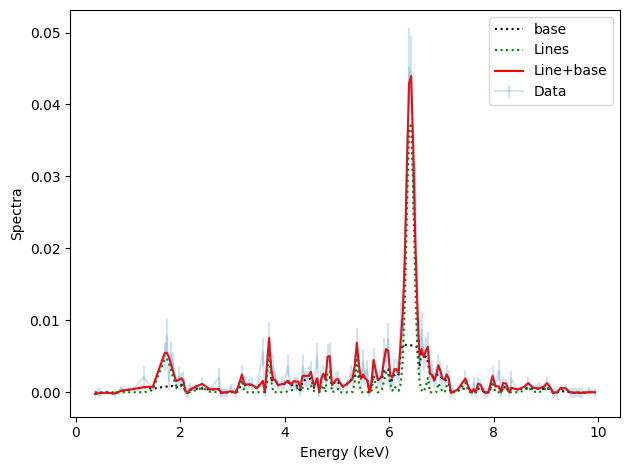

,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,1.723098,0.106224,0.004762,0.057076,0.051994,0.000988,0.000848,0.005233,0.001439,3.310066,0.721138,0.001268,0.000674,1056.840180,0.01
1,2.020009,0.042951,0.000813,0.090650,0.096632,0.001354,0.001043,0.001569,0.000924,0.880431,0.201420,0.000088,0.000245,inf,0.01
2,2.397862,0.081581,0.000637,0.311216,0.279566,0.001614,0.000542,0.001192,0.000567,1.123720,0.374746,0.000130,0.000555,240.539801,0.01
3,3.170500,0.025173,0.001816,0.081766,0.036752,0.002705,0.000780,0.002473,0.000777,2.336755,0.520275,0.000115,0.000239,97.946703,0.76
4,3.696944,0.026663,0.005978,0.009613,0.007220,0.001511,0.001612,0.007593,0.001300,4.597864,0.649765,0.000400,0.000148,244.479429,1.00


In [25]:
xmm_lines = find_emission_lines(
    rx_snr,
    ry_snr,
    rsy_snr,
    show_plot=True,
    output_dir=results_dir,
    plot_name="xmm_bliss_fit.png",
)

xmm_lines.head()

In [26]:
xmm_lines.to_csv(results_dir / "xmm_candidate_lines.csv", index=False)
print("Saved:", results_dir / "xmm_candidate_lines.csv")
print("Number of candidates:", len(xmm_lines))

Saved: /Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-51-49_bliss/xmm_candidate_lines.csv
Number of candidates: 25


## 5. Atomic-line identification

BLiSS detection is blind. Identification is a separate optional step.

Here we add the most probable compatible ion within a Doppler velocity window.

In [27]:
xmm_identified = add_most_probable_ion(xmm_lines, v_doppler_kms=1200)
xmm_identified.to_csv(results_dir / "xmm_identified_lines.csv", index=False)
xmm_identified.head()

,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,fe_xxvi,1.728918,-1009.153202,1.723098,0.106224,0.004762,0.057076,0.051994,0.000988,0.000848,0.005233,0.001439,3.310066,0.721138,0.001268,0.000674,1056.840180,0.01
1,p_vi,2.018563,214.752450,2.020009,0.042951,0.000813,0.090650,0.096632,0.001354,0.001043,0.001569,0.000924,0.880431,0.201420,0.000088,0.000245,inf,0.01
2,s_xii,2.393379,561.626566,2.397862,0.081581,0.000637,0.311216,0.279566,0.001614,0.000542,0.001192,0.000567,1.123720,0.374746,0.000130,0.000555,240.539801,0.01
3,ar_vi,3.179082,-809.262142,3.170500,0.025173,0.001816,0.081766,0.036752,0.002705,0.000780,0.002473,0.000777,2.336755,0.520275,0.000115,0.000239,97.946703,0.76
4,ca_x,3.705666,-705.685880,3.696944,0.026663,0.005978,0.009613,0.007220,0.001511,0.001612,0.007593,0.001300,4.597864,0.649765,0.000400,0.000148,244.479429,1.00


In [35]:
all_xmm_identified = get_all_compatible_lines(xmm_lines, v_doppler_kms=200)
all_xmm_identified[0]

,ion,energy_keV,doppler_kms
0,si_x,1.722649,78.289522
1,si_x,1.722122,169.933405
2,si_x,1.722074,178.276946
3,si_x,1.722697,69.951542
4,fe_xxiii,1.723343,-42.539731


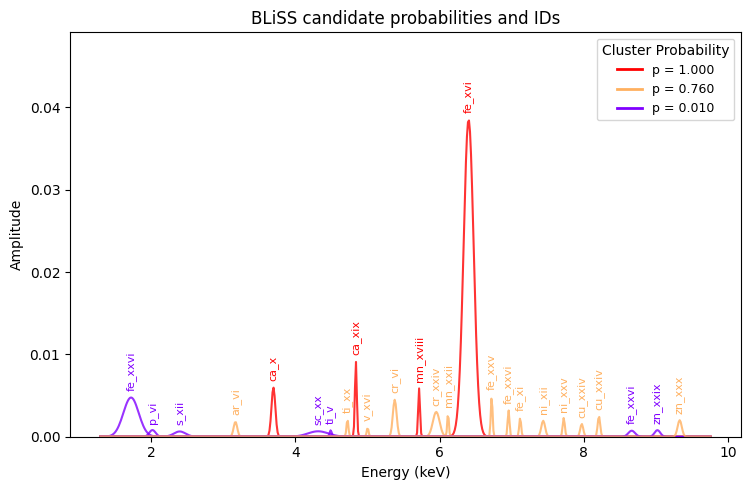

In [36]:
fig, ax = plot_line_prob(xmm_identified, show=False)
ax.set_title("BLiSS candidate probabilities and IDs")

fig.savefig(
    results_dir / "xmm_line_probability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 6. Load a spectrum from FITS products

This is the new input route.

The FITS loader uses `astropy` and can read:

- a source spectrum file (`pha_path`),
- an optional background spectrum (`background_path`),
- an optional RMF file (`rmf_path`) to obtain the energy grid from the `EBOUNDS` extension.

The loader returns a `Spectrum` container by default.

In [37]:
fits_dir = PROJECT_ROOT / "examples" / "fits_spectrum_data"
print(sorted(p.name for p in fits_dir.iterdir()))

['bkglp.fits', 'med4.ds', 'r_plateau.rmf', 'test_lines.sl']


In [39]:
pha_path = fits_dir / "med4.ds"
bkg_path = fits_dir / "bkglp.fits"
rmf_path = fits_dir / "r_plateau.rmf"

fits_spectrum = load_fits_spectrum(
    pha_path=pha_path,
    background_path=bkg_path,
    rmf_path=rmf_path,
    subtract_background=True,
)


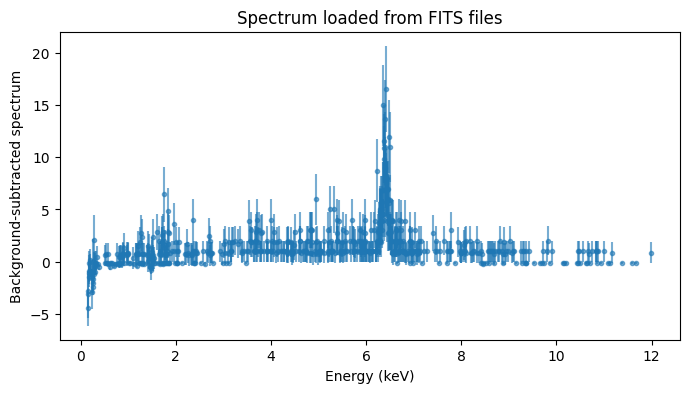

In [40]:
plt.figure(figsize=(8, 4))
plt.errorbar(
    fits_spectrum.energy,
    fits_spectrum.values,
    yerr=fits_spectrum.uncertainties,
    fmt=".",
    alpha=0.6,
)
plt.xlabel("Energy (keV)")
plt.ylabel("Background-subtracted spectrum")
plt.title("Spectrum loaded from FITS files")
plt.show()

## 7. Run BLiSS on the FITS-loaded spectrum

The science pipeline does not care whether the spectrum came from a text file or FITS files. Once loaded, it receives arrays.

Error fitting block 56: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 102: Optimal parameters not found: The maximum number of function evaluations is exceeded.


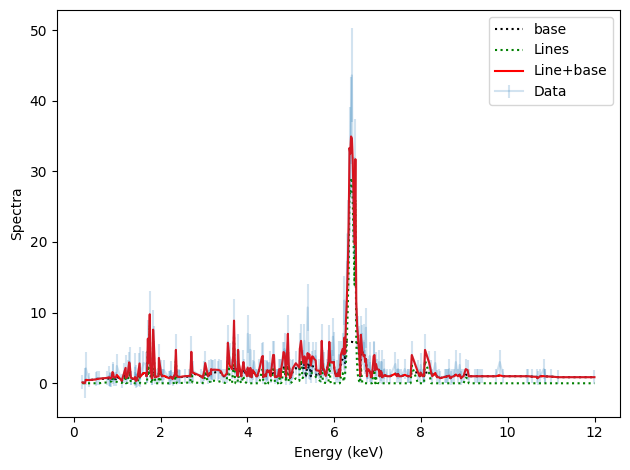

,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,0.906850,0.106653,0.283068,0.424624,0.632653,9.735241e-01,0.661234,1.038114,1.088344,0.260091,0.221780,0.075675,5.188878e-01,133.353762,0.12
1,0.903287,0.002769,45.013752,0.032838,0.097518,1.577811e+04,0.794956,1.587763,1.236580,36.401818,0.332732,0.312472,1.100783e+02,NaN,1.00
2,1.178785,0.006124,35.380486,0.024739,0.058307,2.731430e+03,1.105316,2.175527,1.317492,26.854412,0.326200,0.543075,4.224392e+01,NaN,1.00
3,1.280668,0.016856,1.733008,0.020746,0.016228,1.293743e+00,1.255447,2.725176,1.444934,1.199368,0.369221,0.073222,8.920623e-02,55.871529,0.12
4,1.507900,0.003440,68.351978,488.712798,2098.651075,3.518820e+08,1.409535,2.801405,1.783365,38.327533,0.330537,0.589352,3.055270e+06,NaN,1.00


In [45]:
fx, fy, fsy = fits_spectrum.energy, fits_spectrum.values, fits_spectrum.uncertainties
valid = np.isfinite(fx) & np.isfinite(fy) & np.isfinite(fsy) & (fsy > 0)
fx, fy, fsy = fx[valid], fy[valid], fsy[valid]

# Optional: keep only positive values for the current emission-line workflow.
pos = fy > 0
fx, fy, fsy = fx[pos], fy[pos], fsy[pos]

# Use a modest rebinning for demonstration.
frx, fry, frsy = rebin_resolution(fx, fy, fsy, 0.02)

fits_lines = find_emission_lines(
    frx,
    fry,
    frsy,
    show_plot=True,
    output_dir=results_dir,
    plot_name="fits_bliss_fit.png",
)
fits_lines.to_csv(results_dir / "fits_candidate_lines.csv", index=False)
fits_lines.head()